## Task 1 Iris Classification
Yuxi Zhou

In [2]:
# Import core libraries for data manipulation and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Import scikit-learn dataset and modelling utilities
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Configure plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

### Part 1: EDA

In [3]:
#Import the dataset
iris_raw = load_iris()

# Construct pandas DataFrame
df = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)
df['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)

# Display the first 5 records
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Check dataset dimensions, data types, and non-null values
print("Dataset Overview:")
df.info()
print("Missing Values Check:")
print(df.isnull().sum())
print("Distribution of Species:")
print(df['species'].value_counts())
print("Statistical Summary of Features:")
df.describe()

Dataset Overview:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB
Missing Values Check:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64
Distribution of Species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
Statistical Summary of Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Part 2 Data Visualisations

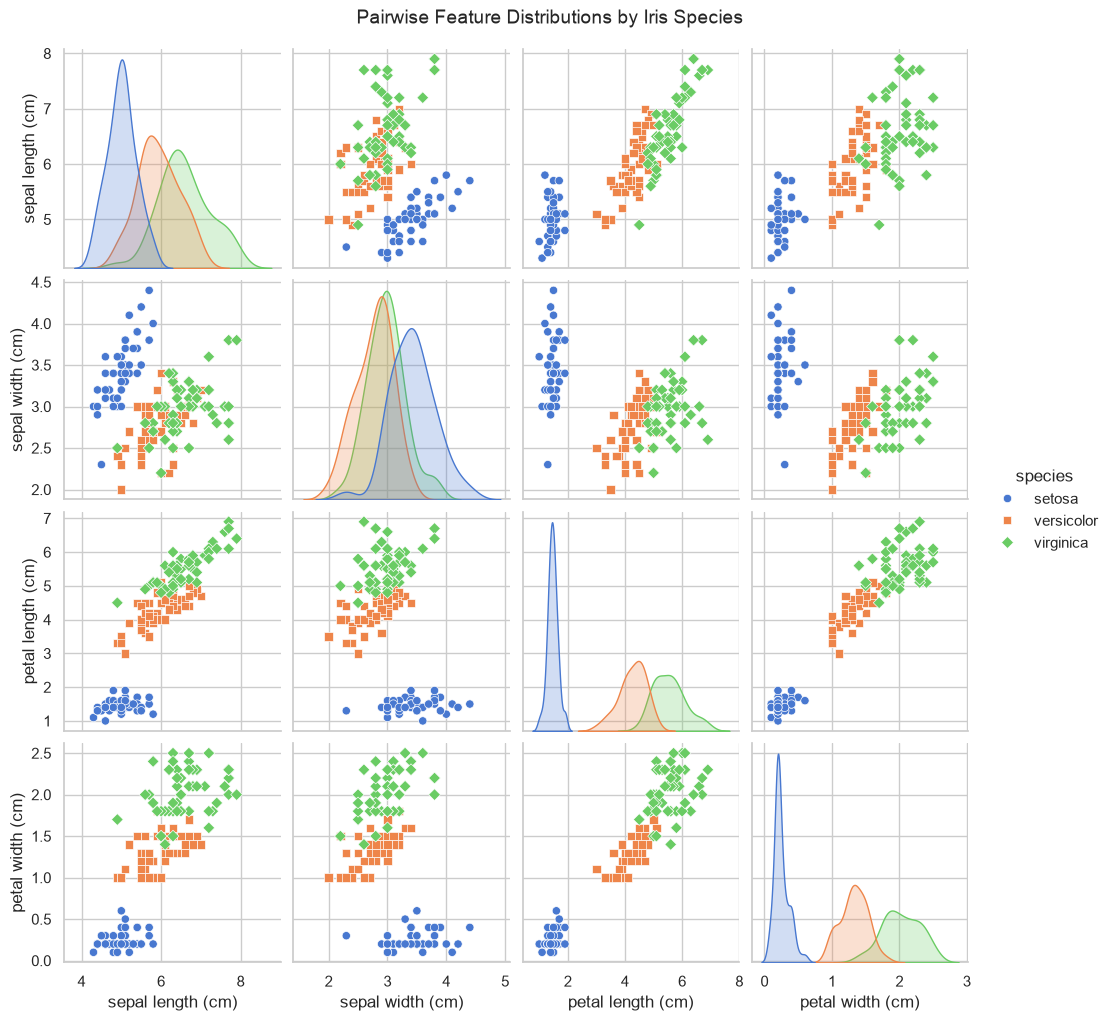

In [5]:
# Pairplot: pairwise relationships across all features colored by species
pairplot_fig = sns.pairplot(df, hue='species', height=2.5, markers=["o", "s", "D"])
pairplot_fig.fig.suptitle("Pairwise Feature Distributions by Iris Species", y=1.02, fontsize=14)
plt.show()

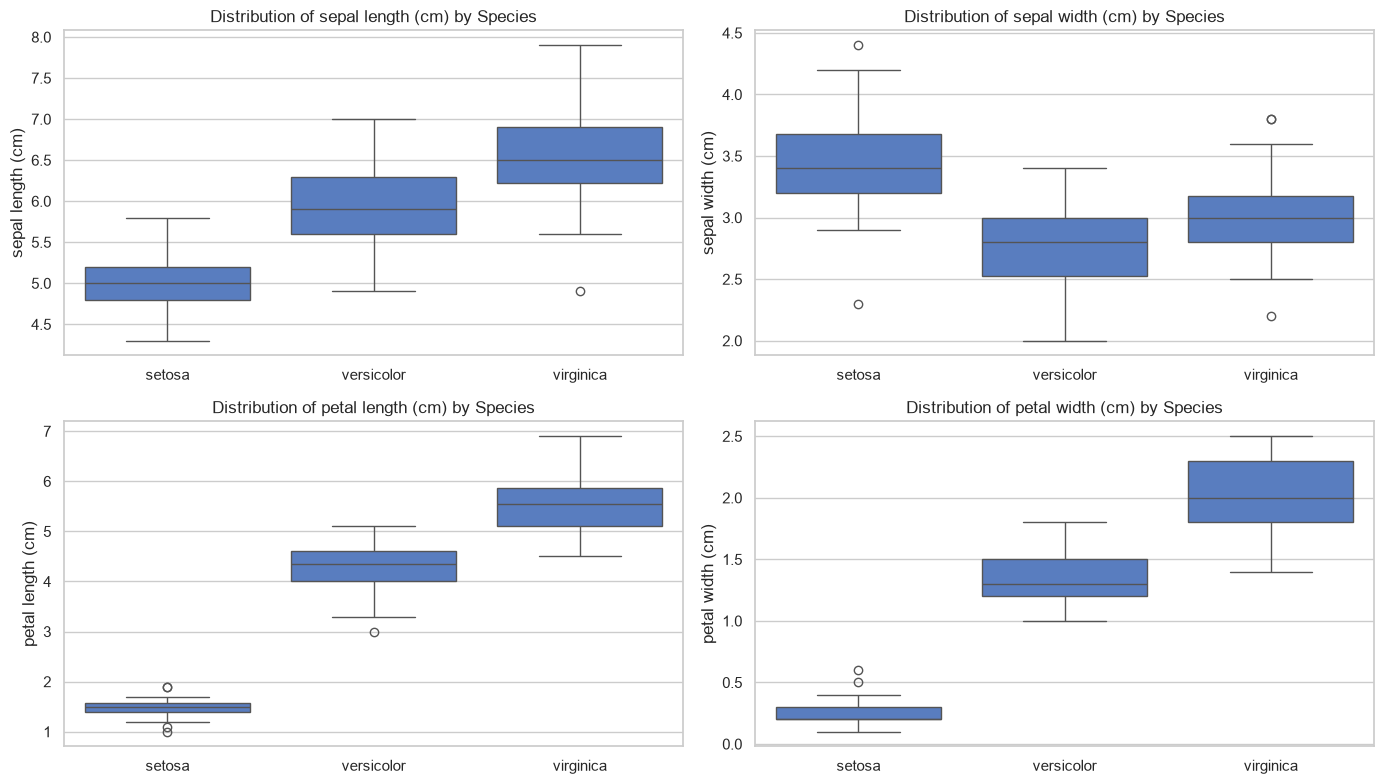

In [6]:
# Box plots: feature distribution for each iris species
plt.figure(figsize=(14, 8))
features = iris_raw.feature_names

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='species', y=col, data=df)
    plt.title(f"Distribution of {col} by Species", fontsize=12)
    plt.xlabel("")

plt.tight_layout()
plt.show()

## Part 3 Train/Test Data Split

In [7]:
# Separate features (X) and ground-truth targets (y)
X = df[features]
y = df['species']

# Split the dataset into 80% train and 20% test
# stratify=y guarantees equal class proportions in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Training set dimensions: {X_train.shape}")
print(f"Testing set dimensions:  {X_test.shape}")

Training set dimensions: (120, 4)
Testing set dimensions:  (30, 4)


## Part 5 Model Training and Evaluation

### Part 5.1 Logistic Regression

In [8]:
# 1. Initialise and train Logistic Regression
lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=200, random_state=42)
)
lr_pipeline.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_lr = lr_pipeline.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"=== Logistic Regression Accuracy: {acc_lr:.4f} ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Accuracy: 0.9333 ===

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Part 5.2 Random Forest Classifier

In [9]:
# 2. Initialise and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=3,random_state=42)
rf_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"=== Random Forest Accuracy: {acc_rf:.4f} ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest Accuracy: 0.9667 ===

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Part 5.3 Confusion Matrix Display

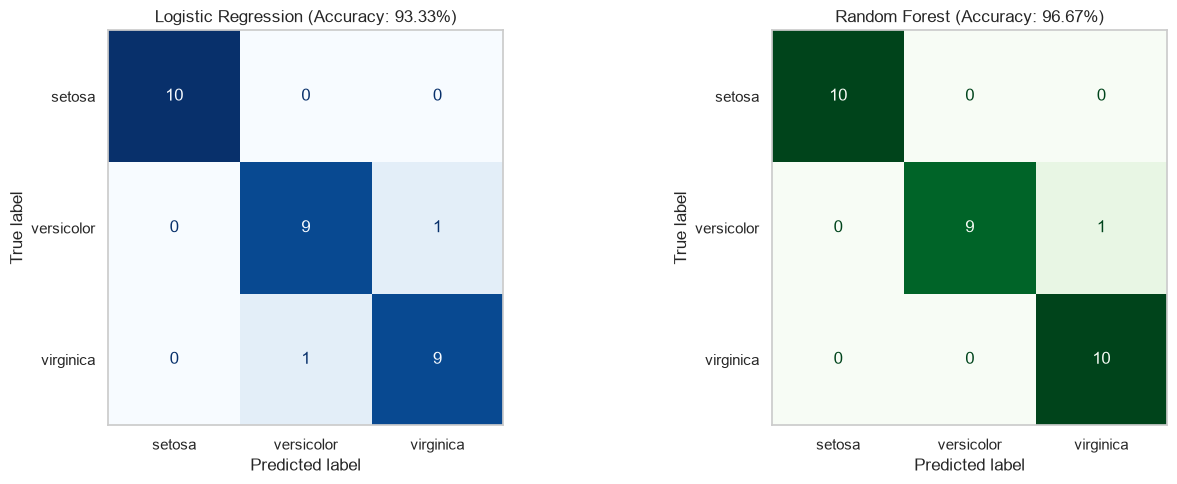

In [10]:
# Plot side-by-side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=iris_raw.target_names)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=iris_raw.target_names)
disp_lr.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f"Logistic Regression (Accuracy: {acc_lr:.2%})", fontsize=12)
axes[0].grid(False)

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=iris_raw.target_names)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=iris_raw.target_names)
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f"Random Forest (Accuracy: {acc_rf:.2%})", fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

### Part 5.4 Feature Importance

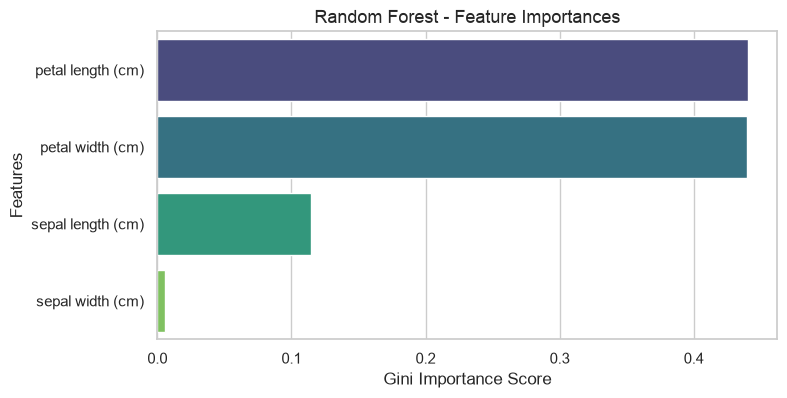

Feature Importance Values:
petal length (cm)    0.440338
petal width (cm)     0.439591
sepal length (cm)    0.114307
sepal width (cm)     0.005764
dtype: float64


In [11]:
# Extract feature importance from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="viridis", legend=False)
plt.title("Random Forest - Feature Importances", fontsize=13)
plt.xlabel("Gini Importance Score")
plt.ylabel("Features")
plt.show()

print("Feature Importance Values:")
print(importances)